# High Patriarchy



* **Karmin, Monika, & _al_.** 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Res._ 25:4 (Apr.), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>.
* **Lippold, Sebastian & _al_.** 2014. "Human paternal and maternal demographic histories: insights from high-resolution Y chromosome and mtDNA sequences". _Investig. Genet._ 24:5 (Sep). <<https://pmc.ncbi.nlm.nih.gov/articles/PMC4174254/>>.


Suppose that we take DNA from and sequence the y-chromosomes of five human males today: call them A, B, C, D, and E. We then find that individual A and B's y-chromosomes are identical except for one single DNA base—they differ only in that there is one Single Nucleotide Polymorphism, one place in their alligned DNA strands where one and only one base is different. We then look at individual C: his DNA also has one single SNP-difference from A's, but a different one than B has; thus there are two SNP-differences between B and C. We look further at D: D has two SNP-differences from B (and three SNP-differences from A). And when we look at E, we find that E has one single SNP-difference from B (and two from A, and one from D).

The way to then bet is that the family lineage of these five different y-chromosome DNA variants forms a tree, like so:

<img src="images/2026-01-26-dna-strands-3.png" width="500" />

Now this tree structure is not guaranteed. But it is the way to bet. How long did this lineage-branching process take? Well, (i) how frequently does DNA mutate? And (ii) what is the chance that a Bienaymé-Galton-Watson branching process sees a new lineage establish itself in the genome sufficiently strongly that it has not (yet) been extinguished?

In [17]:
# galton_watson.py

import random
import math

def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def galton_watson(
    mean_offspring: float,
    max_generations: int = 50,
    initial_population: int = 1
):
    """
    Simulate a single Galton–Watson branching process.

    Returns a list giving population size in each generation,
    starting from generation 0 (the initial population).
    """
    population = initial_population
    history = [population]

    for gen in range(1, max_generations + 1):
        if population == 0:
            history.append(0)
            continue

        next_population = 0
        for _ in range(population):
            next_population += poisson_offspring(mean_offspring)

        population = next_population
        history.append(population)

        if population == 0:
            # Once extinct, we can break early if desired
            break

    return history


if __name__ == "__main__":
    # Example
    mean_offspring = 1.01
    max_generations = 50

    history = galton_watson(mean_offspring, max_generations=max_generations)
    print("Generation : Population")
    for gen, size in enumerate(history):
        print(f"{gen:10d} : {size}")


Generation : Population
         0 : 1
         1 : 2
         2 : 4
         3 : 5
         4 : 7
         5 : 5
         6 : 3
         7 : 1
         8 : 2
         9 : 4
        10 : 2
        11 : 1
        12 : 1
        13 : 2
        14 : 4
        15 : 3
        16 : 6
        17 : 5
        18 : 5
        19 : 6
        20 : 8
        21 : 12
        22 : 5
        23 : 4
        24 : 5
        25 : 8
        26 : 5
        27 : 7
        28 : 6
        29 : 8
        30 : 7
        31 : 4
        32 : 3
        33 : 2
        34 : 3
        35 : 4
        36 : 7
        37 : 9
        38 : 14
        39 : 12
        40 : 10
        41 : 8
        42 : 6
        43 : 7
        44 : 9
        45 : 10
        46 : 8
        47 : 10
        48 : 17
        49 : 12
        50 : 18


In [19]:
import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length = number of generations simulated
    # (generation 0 is the initial ancestor)
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Number of descendants at generation 50 (or last generation if extinct earlier)
    if len(history) > max_generations:
        # we actually simulated up through generation 50
        descendants_at_50.append(history[max_generations])
    else:
        # process went extinct before generation 50
        descendants_at_50.append(0)

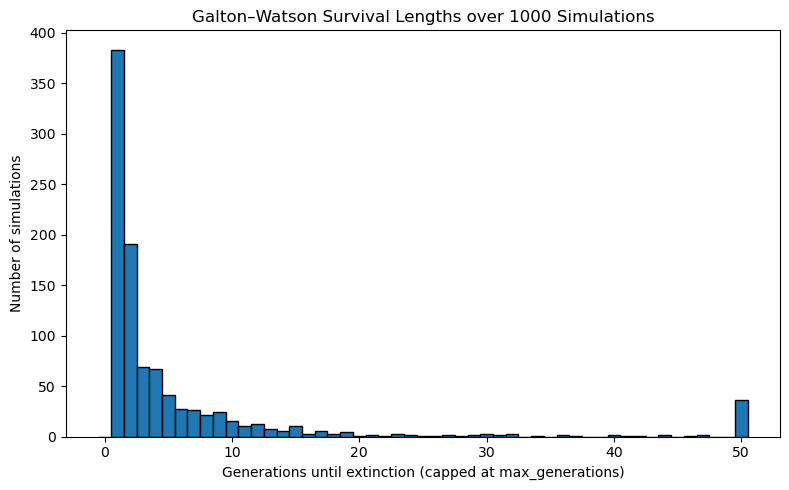

In [20]:
# Histogram of survival lengths
plt.figure(figsize=(8, 5))
plt.hist(
    survival_lengths,
    bins=range(0, max_generations + 2),
    edgecolor="black",
    align="left"
)
plt.xlabel("Generations until extinction (capped at max_generations)")
plt.ylabel("Number of simulations")
plt.title("Galton–Watson Survival Lengths over 1000 Simulations")
plt.tight_layout()
plt.show()

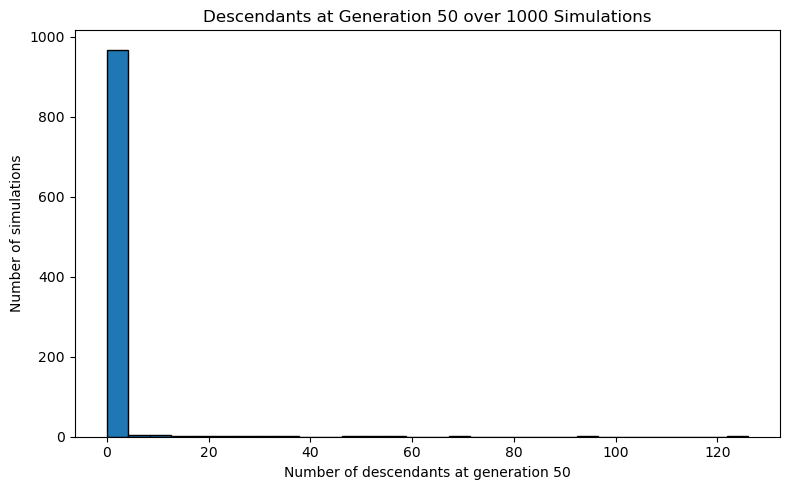

In [21]:
# Histogram of descendants at generation 50
plt.figure(figsize=(8, 5))
plt.hist(
    descendants_at_50,
    bins=30,                  # you can tune this, or use log bins if it’s very skewed
    edgecolor="black"
)
plt.xlabel(f"Number of descendants at generation {max_generations}")
plt.ylabel("Number of simulations")
plt.title(f"Descendants at Generation {max_generations} over 1000 Simulations")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

num_simulations = 1000
mean_offspring = 1.0
max_generations = 50

survival_lengths = []
descendants_at_50 = []

for _ in range(num_simulations):
    history = galton_watson(
        mean_offspring=mean_offspring,
        max_generations=max_generations,
        initial_population=1
    )

    # Survival length
    survival_len = len(history) - 1
    survival_lengths.append(survival_len)

    # Descendants at generation 50 (0 if extinct earlier)
    if len(history) > max_generations:
        descendants_at_50.append(history[max_generations])
    else:
        descendants_at_50.append(0)

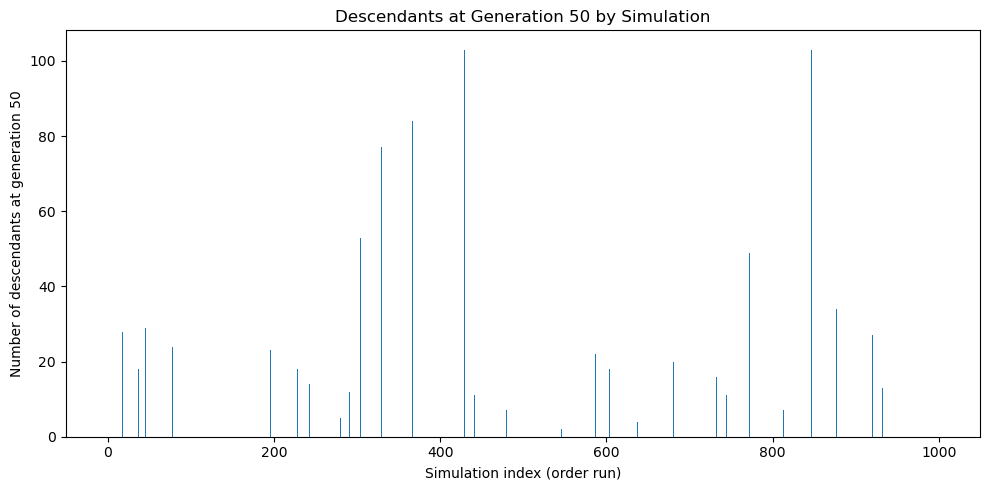

In [22]:
# Bar chart: one bar per simulation
plt.figure(figsize=(10, 5))
plt.bar(
    range(num_simulations),   # x-axis: simulation index 0,1,2,...
    descendants_at_50         # y-axis: descendants at generation 50
)
plt.xlabel("Simulation index (order run)")
plt.ylabel(f"Number of descendants at generation {max_generations}")
plt.title(f"Descendants at Generation {max_generations} by Simulation")
plt.tight_layout()
plt.show()

In [23]:
# extinction probabilities

import math
import pandas as pd

def poisson_G(s, m):
    """
    Offspring pgf G(s) for Poisson(m): G(s) = exp(m (s - 1)).
    """
    return math.exp(m * (s - 1.0))


def extinction_prob_by_generation(m, generations):
    """
    For a Poisson Galton–Watson with mean m and one initial ancestor,
    return a dict: generation -> P(extinct by (at or before) that generation).

    Recursion: q_n = G(q_{n-1}), with q_0 = 0.
    """
    q = 0.0  # q_0
    result = {}
    current_gen = 0

    # We'll iterate up to max(generations), recording values when we hit them.
    max_gen = max(generations)
    targets = set(generations)

    for n in range(1, max_gen + 1):
        q = poisson_G(q, m)  # q_n = G(q_{n-1})
        if n in targets:
            result[n] = q

    return result


# Parameters
m_values = [0.95 + 0.01 * i for i in range(0, 10)]  #
gens = [10, 100, 1000, 10000]

rows = []

for m in m_values:
    q_dict = extinction_prob_by_generation(m, gens)
    # Survival probability at generation n = P(Z_n > 0) = 1 - q_n
    row = {"m": m}
    for g in gens:
        row[f"survival_at_{g}"] = 1.0 - q_dict[g]
    rows.append(row)

df = pd.DataFrame(rows)

# Starting from df with columns: m, survival_at_10, survival_at_100, ...

# 1. Melt to long format: one row per (m, generation)
long = df.melt(
    id_vars="m",
    var_name="horizon",
    value_name="survival"
)

# 2. Extract the numeric generation from the 'horizon' string
long["generation"] = long["horizon"].str.extract(r"(\d+)").astype(int)

# 3. Pivot so: rows = generations, columns = m, values = survival probability
flipped = long.pivot(index="generation", columns="m", values="survival")

# 4. Sort nicely (optional)
flipped = flipped.sort_index(axis=0).sort_index(axis=1)

# Multiply by 100 so entries are in percent units
flipped_pct = flipped * 100.0

# Print with two decimal places and a % sign
def fmt(x):
    return f"{x:.2f}%"

print(flipped_pct.to_string(float_format=fmt))


m            0.95   0.96   0.97   0.98   0.99   1.00   1.01   1.02   1.03   1.04
generation                                                                      
10         11.87% 12.61% 13.39% 14.18% 14.99% 15.82% 16.67% 17.54% 18.42% 19.32%
100         0.06%  0.13%  0.28%  0.59%  1.11%  1.94%  3.07%  4.47%  6.05%  7.72%
1000        0.00%  0.00%  0.00%  0.00%  0.00%  0.20%  1.97%  3.90%  5.77%  7.59%
10000       0.00%  0.00%  0.00%  0.00%  0.00%  0.02%  1.97%  3.90%  5.77%  7.59%


In [26]:
import math
import pandas as pd

def poisson_G(s, m):
    """
    Offspring pgf G(s) for Poisson(m): G(s) = exp(m (s - 1)).
    """
    return math.exp(m * (s - 1.0))

def extinction_prob_by_generation(m, generations):
    """
    For a Poisson Galton–Watson with mean m and one initial ancestor,
    return a dict: generation -> P(extinct by (at or before) that generation).

    Recursion: q_n = G(q_{n-1}), with q_0 = 0.
    """
    q = 0.0  # q_0
    result = {}
    max_gen = max(generations)
    targets = set(generations)

    for n in range(1, max_gen + 1):
        q = poisson_G(q, m)  # q_n = G(q_{n-1})
        if n in targets:
            result[n] = q

    return result

# Generations and corresponding years
gens = list(range(100, 2001, 100))     # 100, 200, ..., 2000
years = [25 * g for g in gens]         # 25 * generations

# Requested m values
m_values = [0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.2, 1.5]

rows = []

for g, yr in zip(gens, years):
    row = {"years": yr}
    for m in m_values:
        q_dict = extinction_prob_by_generation(m, [g])
        survival = 1.0 - q_dict[g]      # P(Z_g > 0)
        row[f"m={m:.2f}"] = survival
    rows.append(row)

df_years = pd.DataFrame(rows).set_index("years")

# Convert to percent and pretty-print with two decimals and a % sign
df_years_pct = df_years * 100.0

def fmt_pct(x):
    return f"{x:.2f}%"

print(df_years_pct.to_string(float_format=fmt_pct))


       m=0.99  m=1.00  m=1.01  m=1.02  m=1.03  m=1.04  m=1.05  m=1.20  m=1.50
years                                                                        
2500    1.11%   1.94%   3.07%   4.47%   6.05%   7.72%   9.43%  31.37%  58.28%
5000    0.30%   0.98%   2.27%   3.96%   5.78%   7.59%   9.37%  31.37%  58.28%
7500    0.10%   0.66%   2.07%   3.91%   5.77%   7.59%   9.37%  31.37%  58.28%
10000   0.04%   0.50%   2.01%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
12500   0.01%   0.40%   1.99%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
15000   0.00%   0.33%   1.98%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
17500   0.00%   0.28%   1.98%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
20000   0.00%   0.25%   1.97%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
22500   0.00%   0.22%   1.97%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
25000   0.00%   0.20%   1.97%   3.90%   5.77%   7.59%   9.37%  31.37%  58.28%
27500   0.00%   0.18%   1.97%   3.90%   5.77%   7.59%   9.37%  3

In [ ]:
import random
import math
import pandas as pd


def poisson_offspring(lmbda: float) -> int:
    """
    Draw a single Poisson(lmbda) random variable using the
    classic 'count arrivals' algorithm (no NumPy needed).
    """
    L = math.exp(-lmbda)
    k = 0
    p = 1.0
    while p > L:
        k += 1
        p *= random.random()
    return k - 1


def simulate_two_type_gw(
    m_L: float = 1.0,
    m_H: float = 1.2,
    high_fraction: float = 0.1,
    max_generations: int = 50,
    initial_population: int = 100,
):
    """
    Two-type Galton–Watson process…
    """

    # Allow 0 ≤ high_fraction ≤ 1
    if not (0.0 <= high_fraction <= 1.0):
        raise ValueError("high_fraction must be in [0, 1].")

    num_H0 = int(round(high_fraction * initial_population))
    num_L0 = initial_population - num_H0
    population_types = (["H"] * num_H0) + (["L"] * num_L0)

    history = [
        {
            "generation": 0,
            "H": num_H0,
            "L": num_L0,
            "total": initial_population,
            "m_L": m_L,
            "m_H": m_H,
        }
    ]

    for gen in range(1, max_generations + 1):
        next_types = []
        for t in population_types:
            lam = m_H if t == "H" else m_L
            k = poisson_offspring(lam)
            next_types.extend([t] * k)

        num_H = next_types.count("H")
        num_L = next_types.count("L")
        total = num_H + num_L

        history.append(
            {
                "generation": gen,
            "H": num_H,
            "L": num_L,
            "total": total,
            "m_L": m_L,
            "m_H": m_H,
            }
        )

        population_types = next_types
        if total == 0:
            break

    df = pd.DataFrame(history)
    df["years"] = 25 * df["generation"]
    df["H_share"] = df["H"] / df["total"].where(df["total"] > 0, float("nan"))
    return df.set_index("years")




# Example usage:

results = simulate_two_type_gw(
    m_L = 1.0,
    m_H = 1.2,
    high_fraction = 0.05,   # share of high-fertility founders
    max_generations = 50,
    initial_population = 1000,
)

# Add population share of high-fertility lineages (numeric)
results["H_share_pct"] = 100.0 * results["H"] / results["total"]

# Replace 'generation' with 'years = 25 * generation'
results["years"] = 25 * results["generation"]
results = results.drop(columns=["generation"]).set_index("years")

# Format H_share_pct with two decimals and a percent sign for display
results["H_share_pct"] = results["H_share_pct"].map(lambda x: f"{x:.2f}%")

print(results)


In [ ]:
import pandas as pd

# Parameter grids
H_share_grid = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05]   # founding high-fertility fraction
m_H_grid = [1.0, 1.01, 1.02, 1.05, 1.10, 1.20]            # high-fertility lineage mean

target_generation = 50
initial_population = 10000

# Prepare empty DataFrame: rows = m_H, columns = H_share
summary = pd.DataFrame(
    index=[f"m_H={m:.2f}" for m in m_H_grid],
    columns=[f"H0={h:.2f}" for h in H_share_grid],
    dtype=float,
)

for m_H in m_H_grid:
    row_label = f"m_H={m_H:.2f}"
    for H0 in H_share_grid:
        # Run the two-type GW simulation
        df = simulate_two_type_gw(
            m_L=1.0,
            m_H=m_H,
            high_fraction=H0,
            max_generations=target_generation,
            initial_population=initial_population,
        )

        # Pick out generation 50; there should be exactly one row
        gen50 = df[df["generation"] == target_generation]
        if len(gen50) == 0 or gen50["total"].iloc[0] == 0:
            # If the population has gone extinct, treat high-share as 0
            H_share_pct = 0.0
        else:
            H_share_pct = 100.0 * gen50["H_share"].iloc[0]

        col_label = f"H0={H0:.2f}"
        summary.loc[row_label, col_label] = H_share_pct

# Pretty-print with two decimals and a % sign
summary_formatted = summary.applymap(lambda x: f"{x:.2f}%" if pd.notna(x) else "NaN")
print(summary_formatted.to_string())


One we have estimates of (i) and (ii), we can then take y-chromosome DNA lineage-variants sequenced from today's human population, and then estimate how far in the past the mutations that established each of these lineage-variants took place. That is what Monika Karman & _al._ (2015) do in their supplemental "Table S7. Age estimates of Y chromosome clades reported in Figure S3". This set of numbers is then very interesting. Why? Because the simple counts-by-century of these estimated lineage-origin dates gives us estimates back into the past of the product of:

1. the chance of single-nucleotide mutations in the y chromosome
2. times the then-size of the male human population,
3. times the chance a single-indiviual male y-chromosome lineage then gets established in the genome—is not wiped out over the next ten generations or so of the Bienaymé–Galton–Watson branching process starting at value 1.

So let's see what Karmin & _al._'s DNA-sequencing exercise tells us:

In [ ]:
# loading & checking our data

import pandas as pd     # importing the python data analysis library

y_chromosomes = pd.Series([253884, 148050, 143437, 99802, 71760, 71048, 68555, 64034, 54140, 51557, 51328, 50865, 50460, 49866, 49346, 49089, 48995, 48871, 48703, 48572, 48486, 48463, 48142, 47932, 47628, 47429, 45979, 45938, 45610, 45439, 43837, 43782, 41900, 41341, 40662, 35383, 35282, 34042, 33417, 33103, 32903, 31899, 30261, 29950, 29435, 28894, 28891, 28094, 26492, 26481, 24824, 24240, 23729, 23497, 22806, 21111, 20912, 20773, 20021, 19494, 19405, 19153, 18895, 18807, 18734, 18506, 18203, 17609, 17445, 17090, 16870, 16781, 16728, 16538, 16392, 16315, 15959, 15802, 15680, 15557, 15444, 15235, 15035, 14889, 14771, 14741, 14674, 14632, 13823, 13229, 12839, 12609, 12474, 12131, 11659, 11357, 10811, 10789, 9882, 9373, 9315, 8596, 8506, 8465, 8411, 8374, 7545, 7455, 7348, 7147, 6641, 6605, 6594, 5993, 5965, 5884, 5747, 5735, 5618, 5596, 5590, 5588, 5558, 5556, 5542, 5538, 5511, 5491, 5465, 5451, 5443, 5409, 5401, 5390, 5368, 5359, 5349, 5343, 5325, 5323, 5322, 5298, 5264, 5251, 5247, 5229, 5228, 5218, 5206, 5181, 5177, 5144, 5121, 5119, 5117, 5097, 5084, 5076, 5068, 5063, 5061, 5021, 5018, 4994, 4992, 4991, 4986, 4973, 4970, 4950, 4935, 4931, 4923, 4885, 4882, 4868, 4858, 4847, 4838, 4837, 4833, 4829, 4824, 4819, 4799, 4762, 4758, 4739, 4727, 4724, 4719, 4702, 4694, 4693, 4672, 4645, 4621, 4558, 4551, 4450, 4398, 4339, 4314, 4291, 4236, 4180, 4113, 4112, 4082, 4048, 3973, 3860, 3812, 3809, 3717, 3624, 3615, 3579, 3488, 3484, 3431, 3372, 3353, 3292, 3258, 3210, 3167, 3102, 3091, 3049, 3023, 2925, 2905, 2804, 2774, 2764, 2739, 2687, 2638, 2617, 2562, 2549, 2524, 2480, 2465, 2403, 2379, 2325, 2323, 2274, 2242, 2237, 2226, 2222, 2130, 2126, 2097, 2031, 2011, 1949, 1837, 1836, 1825, 1810, 1792, 1715, 1674, 1647, 1589, 1588, 1582, 1467, 1461, 1452, 1419, 1241, 1180, 1174, 1102, 1058, 958, 929, 899, 870, 866, 833, 831, 828, 823, 803, 802, 799, 760, 719, 699, 690, 688, 677, 657, 651, 649, 636, 629, 627, 599, 598, 594, 587, 583, 582, 578, 563, 546, 540, 538, 537, 503, 446, 423, 152, 144, 140])
# the list of lineage-origin dates
y_chromosomes.head()    # checking that nothing has gone wrong

In [ ]:
# drawing our first figure 

import matplotlib.pyplot as plt            # importing the python mathematical plotting library

targets_100 = list(range(0, 255001, 100))  # looking at the data every century going back into the past
tolerance_500 = 500                        # deciding to look 500 years back and forward

counts_500 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_500)
    for target in targets_100
] # counting all lineage-origin estimates within 500 years of the current year we are looking at

counts_500_series = pd.Series(counts_500, index=targets_100, name="count_within_500")
counts_500_series.index.name = "target"

plt.figure(figsize=(10, 6))                # prepare the figure
plt.plot(counts_500_series.index, counts_500_series.values, color="darkred", label="Tolerance ±500")
plt.title("Count of y_chromosomes within ±500, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()                                 # show the figure


In [ ]:
# zoom in on the past 10000 years

import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_500 = counts_500_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_500.index,
    subset_500.values,
    color="darkred",
    label="Tolerance ±500"
)

plt.title("Count of y_chromosomes within ±500, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


We are looking backward and forward for 500 years, so the units of the y-axis here are: number of new (surviving) y-chromosome lineages emerging every millennium. And the first thing that jumps out at us is that there are not very many of them. We find (in this sample) only four or so new lineage-origins every millennium—and that is, as we know, the product of (i) the number of y-chromosome mutations times (ii) the chance a lineage then managed to become sufficiently established in the genome that we still see it around today. 

Then, starting after 6000 years ago—after the year -4000—we see a very steep climb in lineage-origin dates, peaking around the year -3000 with a pace of y-chromosome currently-surviving lineage-origins 20 times as rapid as it had been back in the year -4000, and before.

Then, after the year -3000, we see a steep fall: by the year -2000 the pace of y-chromosome currently-surviving lineage-origins has fallen by 3/4, back to maybe 5 times what it had been before the year -4000. After about the year 500 the pace of lineage-origins starts to rise again, and then our data loses focus, as there has not been enough time for even the luckiest y-chromosome lineage-origins over the past 1000 years to have spread widely enough to show up in our sample.

In [ ]:
import matplotlib.pyplot as plt

targets_100 = list(range(0, 255001, 100))
tolerance_100 = 100

counts_100 = [
    sum(1 for x in y_chromosomes if abs(x - target) <= tolerance_100)
    for target in targets_100
]

counts_100_series = pd.Series(counts_100, index=targets_100, name="count_within_100")
counts_100_series.index.name = "target"

plt.figure(figsize=(10, 6))
plt.plot(counts_100_series.index, counts_100_series.values, color="darkred", label="Tolerance ±100")
plt.title("Count of y_chromosomes within ±100, by Target Value (step 100)")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# restrict to targets < 10000
subset_100 = counts_100_series.loc[0:10000]

plt.figure(figsize=(10, 6))
plt.plot(
    subset_100.index,
    subset_100.values,
    color="darkred",
    label="Tolerance ±100"
)

plt.title("Count of y_chromosomes within ±100, for Targets < 10,000")
plt.xlabel("Target value")
plt.ylabel("Count of y_chromosomes")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()


### References

* **Bacaër, Nicolas**. _A Short History of Mathematical Population Dynamics_. London: Springer. <<https://link.springer.com/book/10.1007/978-0-85729-115-8>>.
* **Karmin, Monica**. 2015. "A recent bottleneck of Y chromosome diversity coincides with a global change in culture". _Genome Research_. 25:4 (April), pp. 459–466. <<https://genome.cshlp.org/content/25/4/459>>.
* **Shalizi, Cosma**. 2007-25. "Branching Processes". _Bactra Notebooks_. October 2. <<http://bactra.org/notebooks/branching-processes.html>>

======

Let's start over again with random-effects Poisson: . Random‑effects Poisson: an inherited fertility multiplier ￼

A slightly more realistic (and still simulation‑friendly) version is to give each male an individual fertility multiplier ￼, and let that multiplier be partially inherited.

Think:

￼

where ￼ is a baseline mean. To get persistence:

- Let ￼ depend on the father’s ￼.

- E.g. in logs, an AR(1):

￼

The drift term ￼ is there so that ￼ in the stationary distribution. Then we set ￼ and we still have:

￼

In code (pseudo‑Python inside your branching loop):￼

Now:

- ￼ controls persistence of fecundity father→son.

- ￼ controls cross‑sectional spread in fecundity.

- The unconditional mean per male is still ￼, by construction.

This gives you rich lineage‑specific high/low fertility “dynasties” while keeping the global mean fixed.

In [ ]:
# 2026-02-03-econ-196-patriarchy: AR(1) random-effects Poisson branching
import numpy as np
import pandas as pd

def extinction_probabilities_ar1(
    n_lineages: int = 100_000,
    max_generations: int = 200,
    m: float = 1.01,
    rho: float = 0.8,
    sigma: float = 0.3,
    seed: int | None = 0,
    start_in_stationary: bool = False,
) -> pd.DataFrame:
    """
    Simulate lineage extinction probabilities in a Poisson branching process
    with an inherited AR(1) fertility multiplier.

    sons_{i,t} ~ Poisson(phi_{i,t})
    log phi_{i,t} = (1-rho)*mu + rho * log phi_{father(i),t-1} + eps_{i,t},
    eps_{i,t} ~ N(0, sigma^2)

    mu is chosen so that E[phi] = m in the stationary distribution.
    """

    rng = np.random.default_rng(seed)

    # Drift term so that stationary E[phi] = m
    # Stationary log-phi variance: sigma^2 / (1 - rho^2)
    mu = np.log(m) - 0.5 * sigma**2 / (1.0 - rho**2)

    # Track extinction status: True iff lineage has no males by or before t
    extinct = np.zeros(n_lineages, dtype=bool)

    # For convenience, track extinction probability by generation
    extinction_probs = np.zeros(max_generations + 1)

    # Generation 0: start with one male per lineage
    if start_in_stationary:
        # Start phi_0 from stationary lognormal
        var_log_phi = sigma**2 / (1.0 - rho**2)
        log_phi0 = rng.normal(loc=mu, scale=np.sqrt(var_log_phi), size=n_lineages)
        phi_current = np.exp(log_phi0)
    else:
        # Start with homogeneous fertility m
        phi_current = np.full(n_lineages, m, dtype=float)

    # At t=0, no one is extinct yet (we define extinction after reproduction)
    extinction_probs[0] = 0.0

    # Current number of males per lineage
    males_current = np.ones(n_lineages, dtype=int)

    # Main generations loop
    for t in range(1, max_generations + 1):
        # For each lineage, if already extinct, stay extinct
        active = ~extinct & (males_current > 0)
        n_active = active.sum()

        if n_active == 0:
            # Everyone extinct from here on
            extinction_probs[t:] = 1.0
            break

        # Prepare arrays for next generation
        males_next = np.zeros(n_lineages, dtype=int)
        phi_next = np.zeros(n_lineages, dtype=float)

        # For each active lineage, simulate its males individually
        # (we vectorize at lineage level, but not within-lineage males)
        idx_active = np.where(active)[0]

        for idx in idx_active:
            n_males = males_current[idx]
            if n_males == 0:
                continue

            # Father's log fertility for all sons this gen in this lineage
            log_phi_father = np.log(phi_current[idx])

            # Draw idiosyncratic eps for each male's fertility
            eps = rng.normal(loc=0.0, scale=sigma, size=n_males)

            # Sons' log phi from AR(1)
            log_phi_sons = (1.0 - rho) * mu + rho * log_phi_father + eps
            phi_sons = np.exp(log_phi_sons)

            # For each male, draw number of sons ~ Poisson(phi_sons)
            sons_counts = rng.poisson(lam=phi_sons)

            # Total males in next generation in this lineage
            total_sons = sons_counts.sum()
            males_next[idx] = total_sons

            if total_sons > 0:
                # For the "representative" father's phi in the next generation,
                # we can use the mean phi among males that actually reproduced.
                # (Other choices: random pick, or mean over all n_males.)
                phi_next[idx] = phi_sons.mean()
            else:
                phi_next[idx] = 0.0

        # Update extinction status and state
        males_current = males_next
        # A lineage is extinct when it has zero males
        extinct |= males_current == 0
        phi_current = phi_next

        extinction_probs[t] = extinct.mean()

    # Wrap up in a DataFrame for plotting or inspection
    result = pd.DataFrame({
        "generation": np.arange(max_generations + 1),
        "extinction_prob": extinction_probs
    })
    return result


# Example run and quick look
res = extinction_probabilities_ar1(
    n_lineages=100,        # start small
    max_generations=50,      # also keep this modest at first
    m=1.01,
    rho=0.8,
    sigma=0.0,
    seed=42,
)

print(res.head(10))
print(res.tail(10))